In [ ]:
# Scikit-learn ma spójny interfejs dla WSZYSTKICH algorytmów:
# 1. fit(X, y) - uczenie modelu na danych
# 2. predict(X) - predykcja dla nowych danych
# 3. score(X, y) - ewaluacja modelu
# 4. transform(X) - transformacja danych (dla preprocessorów)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y,   test_size=0.3, # 30% na test
                                                            random_state=42, # dla reprodukowalności
                                                            stratify=y # zachowanie proporcji klas
)
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")

# Porównanie różnych algorytmów - TEN SAM interfejs!
models = {
'Logistic Regression': LogisticRegression(max_iter=200),
'Decision Tree': DecisionTreeClassifier(random_state=42),
'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\nPorównanie algorytmów:")
print("-" * 50)
for name, model in models.items():

# TEN SAM kod dla każdego modelu!
    model.fit(X_train, y_train) # Trening
    train_score = model.score(X_train, y_train) # Accuracy na train
    test_score = model.score(X_test, y_test) # Accuracy na test

    print(f"{name:25s} | Train: {train_score:.3f} | Test: {test_score:.3f}")



Rozmiar zbioru treningowego: 105
Rozmiar zbioru testowego: 45

Porównanie algorytmów:
--------------------------------------------------
Logistic Regression       | Train: 0.971 | Test: 0.933
Decision Tree             | Train: 1.000 | Test: 0.933
K-Nearest Neighbors       | Train: 0.971 | Test: 0.978
Random Forest             | Train: 1.000 | Test: 0.889


In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix,
classification_report)
# ========================================
# KROK 1: Wczytanie i eksploracja danych
# ========================================
data = load_breast_cancer()
X = data.data
y = data.target # 0 = malignant (złośliwy), 1 = benign (łagodny)
print("="*60)
print("BREAST CANCER DATASET - Pełny workflow ML")
print("="*60)
print(f"\nRozmiar: {X.shape[0]} próbek, {X.shape[1]} cech")
print(f"Klasy: {data.target_names}")
print(f"Rozkład klas: {np.bincount(y)}")
print(f" - Malignant: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f" - Benign: {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
# ========================================
# KROK 2: Podział na train/test
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y # zachowaj proporcje klas
)
print(f"\nPodział danych:")
print(f" Train: {X_train.shape[0]} próbek")
print(f" Test: {X_test.shape[0]} próbek")

# ========================================
# KROK 3: Preprocessing - standaryzacja
# ========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit + transform na train
X_test_scaled = scaler.transform(X_test) # tylko transform na test!

print(f"\nPo standaryzacji:")
print(f" Mean (train): {X_train_scaled.mean():.6f}")
print(f" Std (train): {X_train_scaled.std():.6f}")
# ========================================
# KROK 4: Trening modelu
# ========================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"\nModel wytrenowany!")
print(f" Liczba iteracji: {model.n_iter_[0]}")
# ========================================
# KROK 5: Predykcja
# ========================================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled) # prawdopodobieństwa

print(f"\nPrzykładowe predykcje (5 pierwszych):")
for i in range(5):
    print(f" Próbka {i}: pred={y_pred[i]}, "
    f"proba=[{y_pred_proba[i][0]:.3f}, {y_pred_proba[i][1]:.3f}], "
    f"true={y_test[i]}")


    
# ========================================
# KROK 6: Ewaluacja
# ========================================
print("\n" + "="*60)
print("EWALUACJA MODELU")
print("="*60)
# Metryki podstawowe
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nMetryki:")

print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-score: {f1:.4f}")
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f" TN={cm[0,0]:3d} FP={cm[0,1]:3d}")
print(f" FN={cm[1,0]:3d} TP={cm[1,1]:3d}")
# Pełny raport
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

BREAST CANCER DATASET - Pełny workflow ML

Rozmiar: 569 próbek, 30 cech
Klasy: ['malignant' 'benign']
Rozkład klas: [212 357]
 - Malignant: 212 (37.3%)
 - Benign: 357 (62.7%)

Podział danych:
 Train: 455 próbek
 Test: 114 próbek

Po standaryzacji:
 Mean (train): -0.000000
 Std (train): 1.000000

Model wytrenowany!
 Liczba iteracji: 19

Przykładowe predykcje (5 pierwszych):
 Próbka 0: pred=0, proba=[1.000, 0.000], true=0
 Próbka 1: pred=1, proba=[0.000, 1.000], true=1
 Próbka 2: pred=0, proba=[0.994, 0.006], true=0
 Próbka 3: pred=1, proba=[0.466, 0.534], true=1
 Próbka 4: pred=0, proba=[1.000, 0.000], true=0

EWALUACJA MODELU

Metryki:
 Accuracy: 0.9825
 Precision: 0.9861
 Recall: 0.9861
 F1-score: 0.9861

Confusion Matrix:
 TN= 41 FP=  1
 FN=  1 TP= 71

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98     

REDUKCJA WYMIAROWOŚCI - PCA na cyfrach

Oryginalny rozmiar: (1797, 64) (64 cechy = 8x8 pikseli)


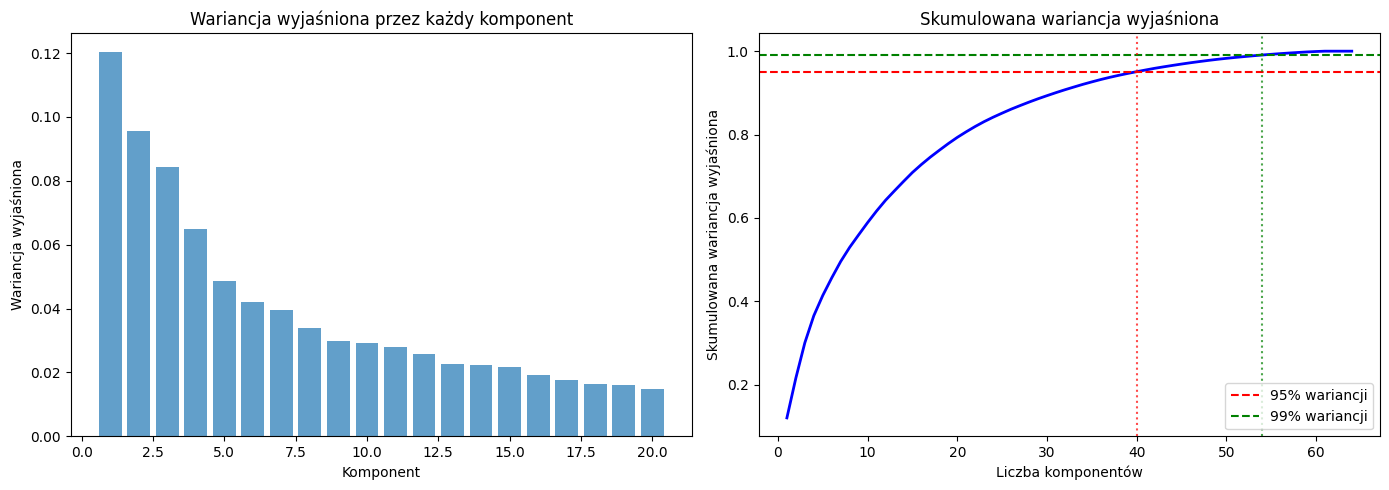


Komponentów dla 95% wariancji: 40
Komponentów dla 99% wariancji: 54

Po PCA do 2D: (1797, 2)
Wariancja wyjaśniona:21.6%


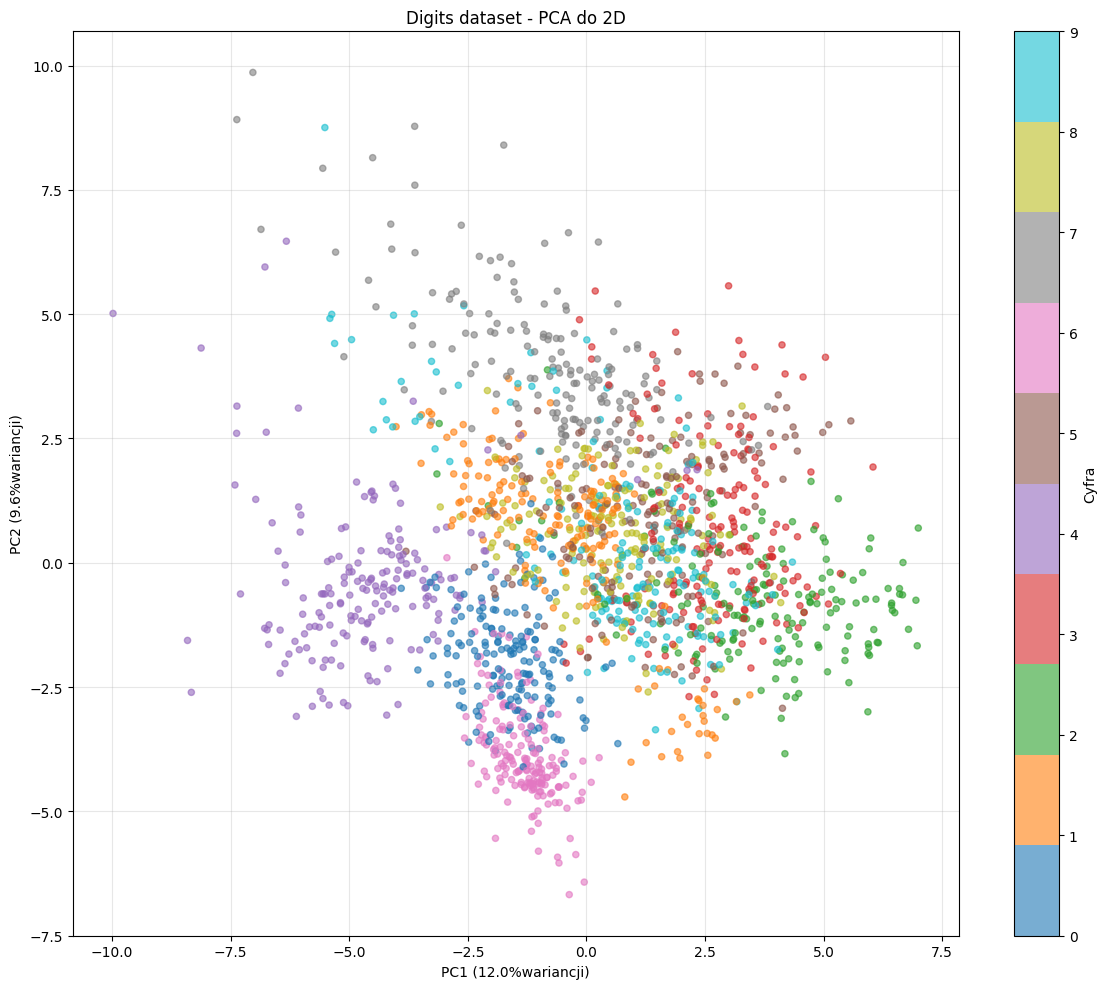

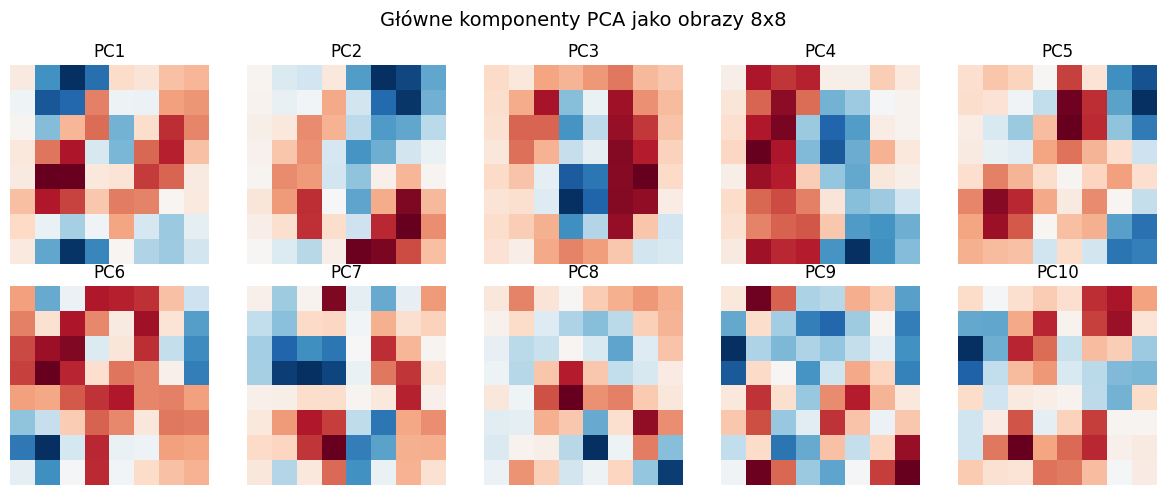

In [2]:
#PCA - reducja wymairowości
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target
print("="*60)
print("REDUKCJA WYMIAROWOŚCI - PCA na cyfrach")
print("="*60)
print(f"\nOryginalny rozmiar: {X.shape} (64 cechy = 8x8 pikseli)")

# Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA z różną liczbą komponentów
pca_full = PCA()
pca_full.fit(X_scaled)

# Skumulowana wariancja wyjaśniona
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wariancja wyjaśniona per komponent
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20],
alpha=0.7)
axes[0].set_xlabel('Komponent')
axes[0].set_ylabel('Wariancja wyjaśniona')
axes[0].set_title('Wariancja wyjaśniona przez każdy komponent')

# Skumulowana wariancja
axes[1].plot(range(1, 65), cumsum_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% wariancji')
n_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_99 = np.argmax(cumsum_variance >= 0.99) + 1
axes[1].axvline(x=n_95, color='r', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_99, color='g', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Liczba komponentów')
axes[1].set_ylabel('Skumulowana wariancja wyjaśniona')
axes[1].set_title('Skumulowana wariancja wyjaśniona')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"\nKomponentów dla 95% wariancji: {n_95}")
print(f"Komponentów dla 99% wariancji: {n_99}")


# PCA do 2D dla wizualizacji
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"\nPo PCA do 2D: {X_pca.shape}")
print(f"Wariancja wyjaśniona:{pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# Wizualizacja 2D
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10',
alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%wariancji)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%wariancji)')
ax.set_title('Digits dataset - PCA do 2D')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cyfra')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wizualizacja głównych komponentów jako obrazy
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(pca_full.components_):
        ax.imshow(pca_full.components_[i].reshape(8, 8), cmap='RdBu')
        ax.set_title(f'PC{i+1}')
        ax.axis('off')
plt.suptitle('Główne komponenty PCA jako obrazy 8x8', fontsize=14)
plt.tight_layout()
plt.show()

WALIDACJA KRZYŻOWA (Cross-Validation)

Logistic Regression:
 Scores per fold: [1.         0.96666667 0.93333333 1.         0.93333333]
 Mean: 0.9667
 Std: 0.0298
 95% CI: [0.9082, 1.0251]

Decision Tree:
 Scores per fold: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
 Mean: 0.9533
 Std: 0.0340
 95% CI: [0.8867, 1.0200]

Random Forest:
 Scores per fold: [0.96666667 0.96666667 0.93333333 0.96666667 0.9       ]
 Mean: 0.9467
 Std: 0.0267
 95% CI: [0.8944, 0.9989]


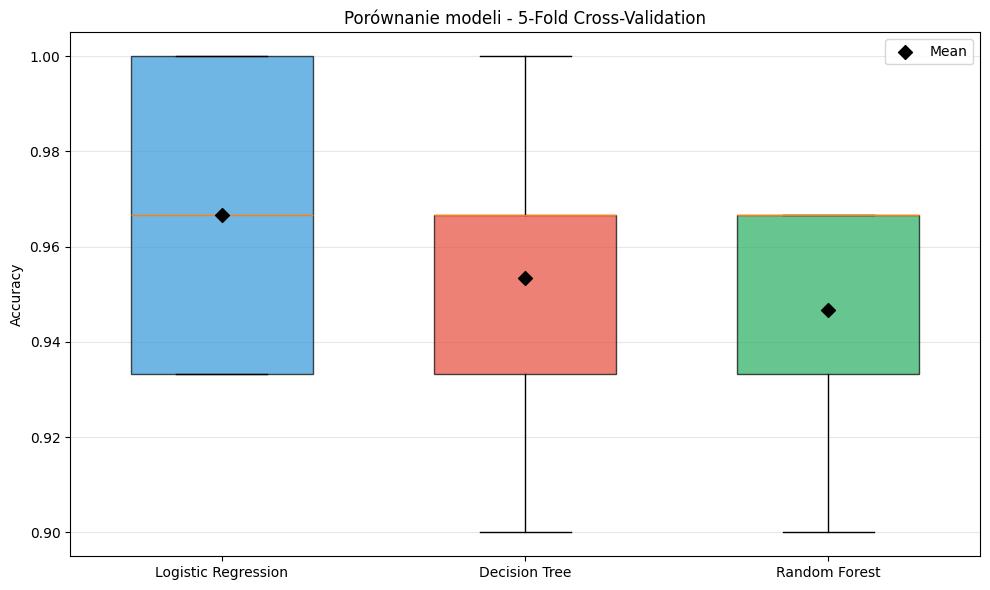

In [1]:
#Cross Validation
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
# Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target
print("="*60)
print("WALIDACJA KRZYŻOWA (Cross-Validation)")
print("="*60)
# Różne modele do porównania
models = {
'Logistic Regression': LogisticRegression(max_iter=200),
'Decision Tree': DecisionTreeClassifier(random_state=42),
'Random Forest': RandomForestClassifier(n_estimators=100,
random_state=42)
}
# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"\n{name}:")
    print(f" Scores per fold: {scores}")
    print(f" Mean: {scores.mean():.4f}")
    print(f" Std: {scores.std():.4f}")
    print(f" 95% CI: [{scores.mean() - 1.96*scores.std():.4f}, "f"{scores.mean() + 1.96*scores.std():.4f}]")
# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(models))
bp = ax.boxplot([results[name] for name in models.keys()],
positions=positions, widths=0.6, patch_artist=True)
colors = ['#3498db', '#e74c3c', '#27ae60']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(models.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Porównanie modeli - 5-Fold Cross-Validation')
ax.grid(True, alpha=0.3, axis='y')
# Dodaj średnie jako punkty
means = [results[name].mean() for name in models.keys()]
ax.scatter(positions, means, c='black', marker='D', s=50, zorder=3,
label='Mean')
ax.legend()
plt.tight_layout()
plt.show()